# PAM2002 Data Science Project
##Facial Emotion Recognition Using CNN and Transfer Learning
##Student: Muhammad Zohaib Khan
##Module: 7PAM2002 Data Science Project
##Semester: A 2025/2026

---

## Research Questions
1. How do different data preprocessing and augmentation methods affect the performance of facial emotion recognition models?
2. How do different CNN architectures compare in extracting facial features for emotion recognition?
3. How does the performance of CNN-based models compare with that of Transfer models for facial emotion recognition from images?
4. How do CNN and Transfer models differ in classification performance and error patterns when evaluated using standard metrics?


## Table of Contents
1. [Environment Setup & Imports](#1)
2. [Dataset Loading](#2)
3. [Exploratory Data Analysis (EDA)](#3)
4. [Data Preprocessing & Class Imbalance Handling](#4)
5. [Data Augmentation & DataLoaders](#5)
6. [Model 1: Simple Custom CNN Model](#6)
7. [Model 2: Hypermodel CNN Fine Tunned](#7)
8. [Model 3: Transfer Learning Model](#8)
9. [Model 4: Fine Tunned Transfer Learning Model](#9)
10. [Model 5: Applying VIT Model](#10)
11. [Model 6: Fine Tunning VIT Model](#11)


# 1. Importing Libraries



In [ ]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.9 MB/s eta 0:00:00


In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import tensorflow as tf
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# 2. Dataset Loading

In [ ]:
dataset_path = "/content/drive/MyDrive/emotion-recognition-dataset/Dataset/dataset/"

print("Dataset path exists:", os.path.exists(dataset_path))
print("Folders/classes:", os.listdir(dataset_path))

Dataset path exists: True
Folders/classes: ['Sad', 'Neutral', 'Surprise', 'Happy', 'Angry', 'Ahegao']


Setting Image and Batch Side

In [ ]:
IMG_SIZE = (64, 64)
BATCH_SIZE = 32

Loading the dataset using Keras:

In [ ]:
train_ds = keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

temp_ds = keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

Found 15454 files belonging to 6 classes.
Using 10818 files for training.
Found 15454 files belonging to 6 classes.
Using 4636 files for validation.


Now spliting the temporary 30% into validation and test sets.

In [ ]:
val_batches = tf.data.experimental.cardinality(temp_ds)
test_ds = temp_ds.take(val_batches // 2)
val_ds = temp_ds.skip(val_batches // 2)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

Class names: ['Ahegao', 'Angry', 'Happy', 'Neutral', 'Sad', 'Surprise']
Number of classes: 6


# 3. Exploratory Data Analysis

**Display Sample Images**

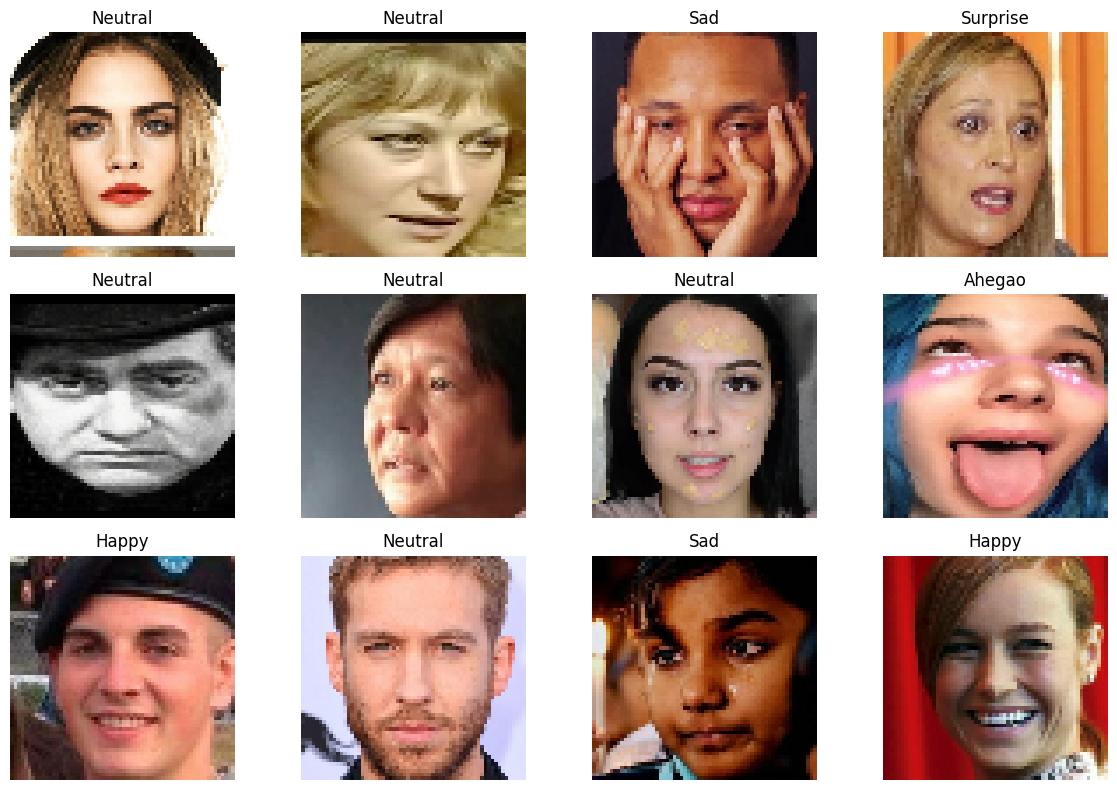

In [ ]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(min(12, len(images))):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

**Class Distribution**

In [ ]:
class_counts = {}

for class_name in class_names:
    class_dir = os.path.join(dataset_path, class_name)
    class_counts[class_name] = len([
        file for file in os.listdir(class_dir)
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ])

print("Class distribution:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

Class distribution:
Ahegao: 1206
Angry: 1313
Happy: 3740
Neutral: 4027
Sad: 3934
Surprise: 1234


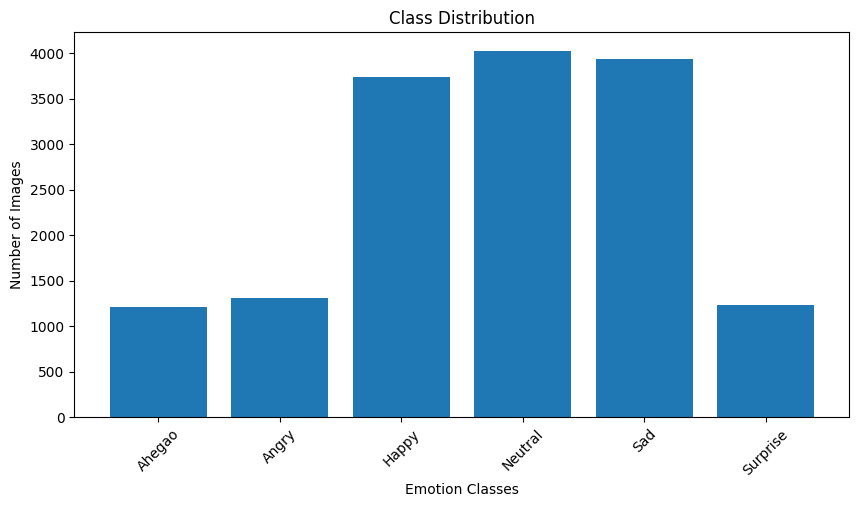

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Emotion Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.show()

# 4. Data Preprocessing & Class Imbalance Handling

Images loaded by image_dataset_from_directory are originally in the range 0 to 255. We will normalize them to 0 to 1 inside the model using a Rescaling layer.
 For imbalance handling, we will calculate class weights.

In [ ]:
all_labels = []

for class_index, class_name in enumerate(class_names):
    class_dir = os.path.join(dataset_path, class_name)

    image_files = [
        file for file in os.listdir(class_dir)
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ]

    all_labels.extend([class_index] * len(image_files))

all_labels = np.array(all_labels)

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(all_labels),
    y=all_labels
)

class_weights = {
    i: class_weights_values[i]
    for i in range(len(class_weights_values))
}

print("Class weights:")
print(class_weights)

Class weights:
{0: np.float64(2.1357103372028745), 1: np.float64(1.9616653973089617), 2: np.float64(0.6886809269162211), 3: np.float64(0.6395993709130039), 4: np.float64(0.6547195390611761), 5: np.float64(2.0872501350621286)}


These weights will be passed to model.fit() later:

In [ ]:
class_weight=class_weights

# 5. Data Augmentation & DataLoaders

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1)
], name="data_augmentation")

**Improve Loading Performance**

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# 6. Defining Simple Custom CNN Model

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(64, 64, 3)),

    layers.Rescaling(1./255),

    data_augmentation,

    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation="softmax")
])

**Model Summery**

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 548,774 (2.09 MB)

 Trainable params: 548,774 (2.09 MB)

 Non-trainable params: 0 (0.00 B)

**Compile the Model**

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train the Simple CNN Model

In [ ]:
EPOCHS = 35

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights
)

Epoch 1/35
339/339 ━━━━━━━━━━━━━━━━━━━━ 447s 341ms/step - accuracy: 0.2308 - loss: 1.7065 - val_accuracy: 0.2925 - val_loss: 1.5736
Epoch 2/35
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3070 - loss: 1.5684 - val_accuracy: 0.2740 - val_loss: 1.6545
Epoch 3/35
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3203 - loss: 1.5044 - val_accuracy: 0.3319 - val_loss: 1.5419
Epoch 4/35
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3449 - loss: 1.4589 - val_accuracy: 0.3795 - val_loss: 1.4406
Epoch 5/35
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3585 - loss: 1.4109 - val_accuracy: 0.4057 - val_loss: 1.3939
Epoch 6/35
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3642 - loss: 1.3928 - val_accuracy: 0.4237 - val_loss: 1.3951
Epoch 7/35
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3805 - loss: 1.3496 - val_accuracy: 0.4082 - val_loss: 1.3714
Epoch 8/35
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3953 - loss: 1.3208 - val_accuracy

**Plot Training and Validation Results**

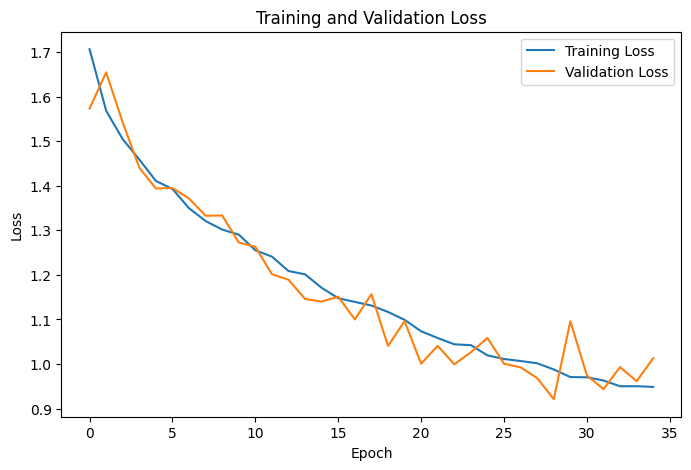

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

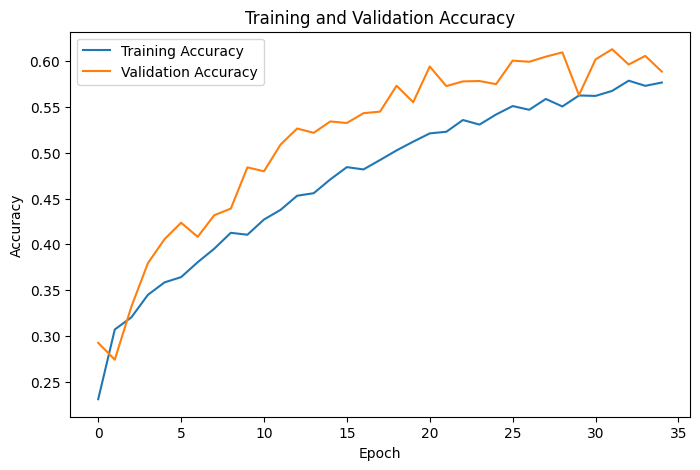

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

# Evaluate on Test Set

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.5803 - loss: 1.0262
Test Loss: 1.0262
Test Accuracy: 0.5803


**Classification Report and Confusion Matrix**

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

      Ahegao       0.96      0.78      0.86       172
       Angry       0.26      0.82      0.39       190
       Happy       0.84      0.70      0.76       502
     Neutral       0.58      0.57      0.57       612
         Sad       0.70      0.35      0.46       623
    Surprise       0.56      0.65      0.60       205

    accuracy                           0.58      2304
   macro avg       0.65      0.64      0.61      2304
weighted avg       0.67      0.58      0.59      2304



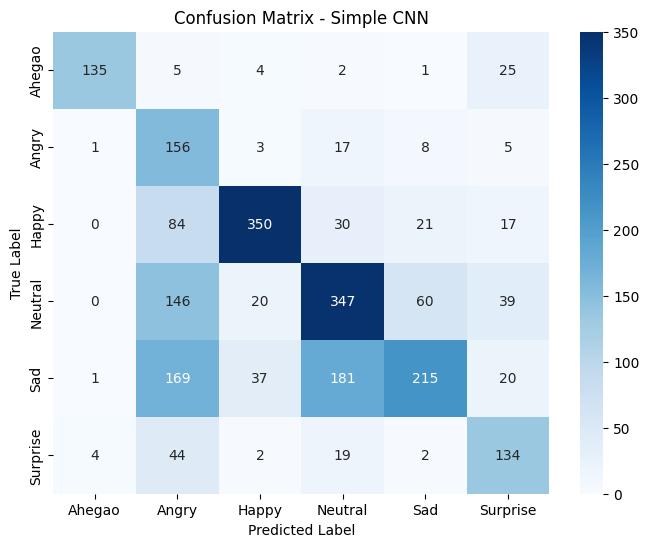

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Simple CNN")
plt.show()

# Showing Sample Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


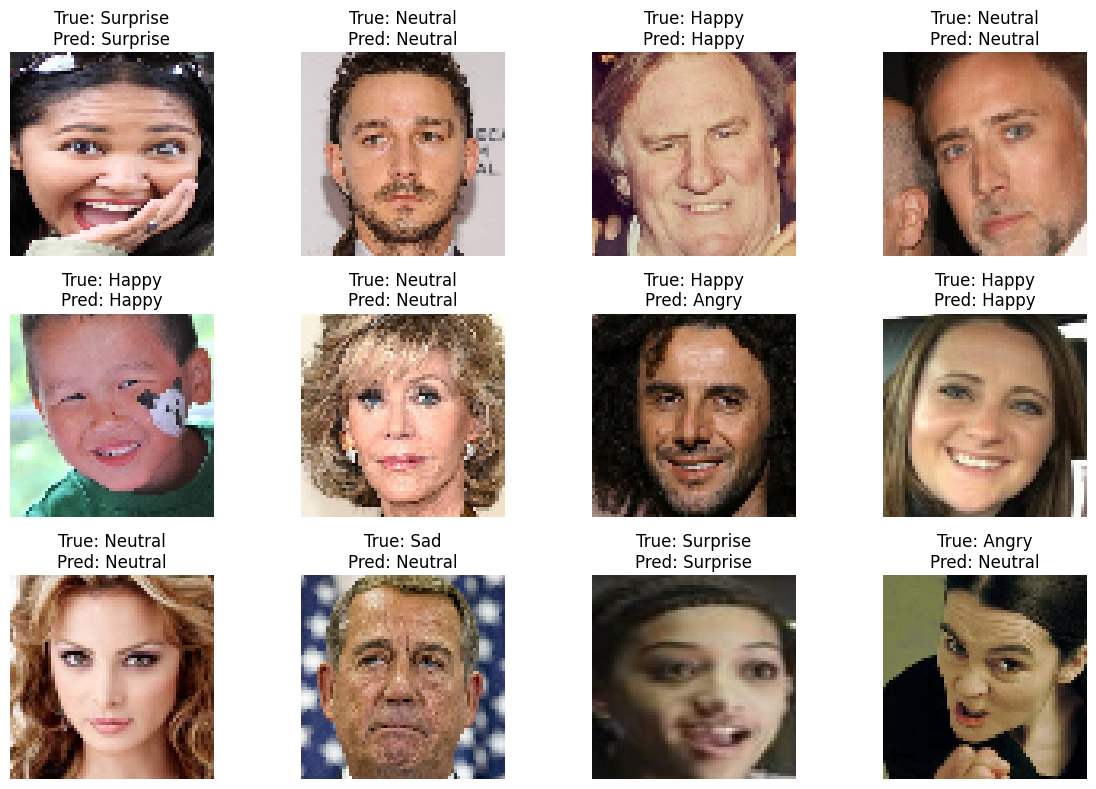

In [ ]:
plt.figure(figsize=(12, 8))

for images, labels in test_ds.take(1):
    predictions = model.predict(images)
    predicted_classes = np.argmax(predictions, axis=1)

    for i in range(min(12, len(images))):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        true_label = class_names[labels[i]]
        predicted_label = class_names[predicted_classes[i]]

        plt.title(f"True: {true_label}\nPred: {predicted_label}")
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
model.save("/content/drive/MyDrive/simple_cnn_emotion_model.keras")

# 7. Defining the Hypermodel
(mean model with hyper parameter tunning)

In [ ]:
def build_safe_tuned_cnn(hp):
    model = keras.Sequential([
        layers.Input(shape=(64, 64, 3)),

        # Normalize pixel values
        layers.Rescaling(1./255),

        # Data augmentation
        data_augmentation,

        # Conv Block 1
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Conv Block 2
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Conv Block 3
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Conv Block 4
        layers.Conv2D(256, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(
            units=hp.Choice("dense_units", values=[64, 128, 256, 512]),
            activation="relu"
        ),
        layers.BatchNormalization(),

        layers.Dropout(
            rate=hp.Choice("dropout_rate", values=[0.2, 0.3, 0.4, 0.5])
        ),

        layers.Dense(num_classes, activation="softmax")
    ])

    learning_rate = hp.Choice(
        "learning_rate",
        values=[1e-3, 5e-4, 1e-4]
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# Create the Tuner

We will use Random Search.
Random Search tests random combinations of hyperparameters. It is simple and effective for a second baseline model.

In [ ]:
tuner_safe = kt.RandomSearch(
    hypermodel=build_safe_tuned_cnn,
    objective="val_accuracy",
    max_trials=20,
    executions_per_trial=1,
    directory="/content/tuning_results",
    project_name="safe_tuned_cnn_bn",
    overwrite=True
)

**View Search Space**

In [ ]:
tuner_safe.search_space_summary()

Search space summary
Default search space size: 3
dense_units (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128, 256, 512], 'ordered': True}
dropout_rate (Choice)
{'default': 0.2, 'conditions': [], 'values': [0.2, 0.3, 0.4, 0.5], 'ordered': True}
learning_rate (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0005, 0.0001], 'ordered': True}


# Run Hyperparameter Tuning

In [ ]:
early_stopping_safe = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
tuner_safe.search(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stopping_safe]
)
# This will train multiple CNN models and select the best one.

Trial 20 Complete [00h 01m 01s]
val_accuracy: 0.6029159426689148

Best val_accuracy So Far: 0.7354202270507812
Total elapsed time: 00h 29m 53s


# Show Best Hyperparameters

In [ ]:
best_hps_safe = tuner_safe.get_best_hyperparameters(num_trials=1)[0]

print("Best Hyperparameters:")
print("Dense Units:", best_hps_safe.get("dense_units"))
print("Dropout Rate:", best_hps_safe.get("dropout_rate"))
print("Learning Rate:", best_hps_safe.get("learning_rate"))

Best Hyperparameters:
Dense Units: 128
Dropout Rate: 0.4
Learning Rate: 0.0005


# Build the Best Model

In [ ]:
best_safe_tuned_model = tuner_safe.hypermodel.build(best_hps_safe)

best_safe_tuned_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 1,701,798 (6.49 MB)

 Trainable params: 1,699,622 (6.48 MB)

 Non-trainable params: 2,176 (8.50 KB)

# Train the Best Tuned CNN Model Fully

After finding the best hyperparameters, train the best model again for more epochs.

In [ ]:
early_stopping_final_safe = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_safe_tuned = best_safe_tuned_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stopping_final_safe]
)

Epoch 1/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.3006 - loss: 1.8828 - val_accuracy: 0.3529 - val_loss: 1.5745
Epoch 2/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.4256 - loss: 1.4764 - val_accuracy: 0.5472 - val_loss: 1.1214
Epoch 3/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.5123 - loss: 1.2364 - val_accuracy: 0.5729 - val_loss: 1.0547
Epoch 4/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.5716 - loss: 1.0875 - val_accuracy: 0.5266 - val_loss: 1.1710
Epoch 5/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.5842 - loss: 1.0363 - val_accuracy: 0.6226 - val_loss: 0.9325
Epoch 6/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.6271 - loss: 0.9270 - val_accuracy: 0.6531 - val_loss: 0.8362
Epoch 7/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.6571 - loss: 0.8737 - val_accuracy: 0.6261 - val_loss: 0.9287
Epoch 8/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.6787 - loss: 0.8126 - val_acc

**Ploting Tuned Model Accuracy and Loss**

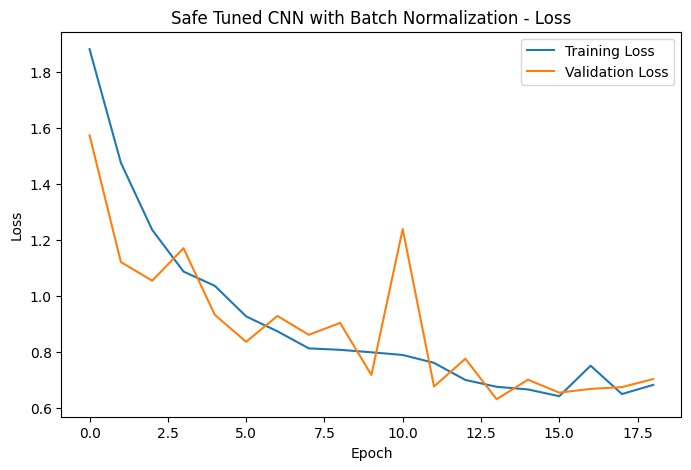

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_safe_tuned.history["loss"], label="Training Loss")
plt.plot(history_safe_tuned.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Safe Tuned CNN with Batch Normalization - Loss")
plt.legend()
plt.show()

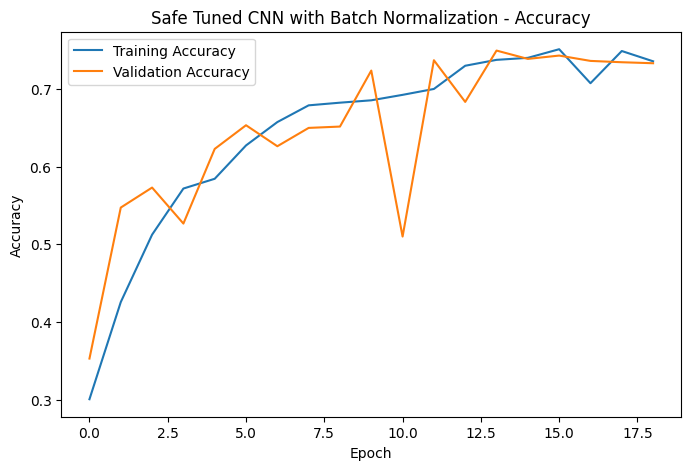

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_safe_tuned.history["accuracy"], label="Training Accuracy")
plt.plot(history_safe_tuned.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Safe Tuned CNN with Batch Normalization - Accuracy")
plt.legend()
plt.show()

# Evaluate Tuned CNN on Test Set

In [ ]:
test_loss_safe, test_accuracy_safe = best_safe_tuned_model.evaluate(test_ds)

print(f"Safe Tuned CNN Test Loss: {test_loss_safe:.4f}")
print(f"Safe Tuned CNN Test Accuracy: {test_accuracy_safe:.4f}")

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7457 - loss: 0.6368
Safe Tuned CNN Test Loss: 0.6368
Safe Tuned CNN Test Accuracy: 0.7457


# Classification Report for Tuned CNN

In [ ]:
y_true_safe = []
y_pred_safe = []

for images, labels in test_ds:
    predictions = best_safe_tuned_model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    y_true_safe.extend(labels.numpy())
    y_pred_safe.extend(predicted_classes)

y_true_safe = np.array(y_true_safe)
y_pred_safe = np.array(y_pred_safe)

In [ ]:
print(classification_report(
    y_true_safe,
    y_pred_safe,
    target_names=class_names
))

              precision    recall  f1-score   support

      Ahegao       0.97      0.95      0.96       172
       Angry       0.77      0.32      0.45       190
       Happy       0.90      0.89      0.90       502
     Neutral       0.70      0.70      0.70       612
         Sad       0.64      0.76      0.69       623
    Surprise       0.70      0.70      0.70       205

    accuracy                           0.75      2304
   macro avg       0.78      0.72      0.73      2304
weighted avg       0.75      0.75      0.74      2304



# Confusion Matrix for Tuned CNN

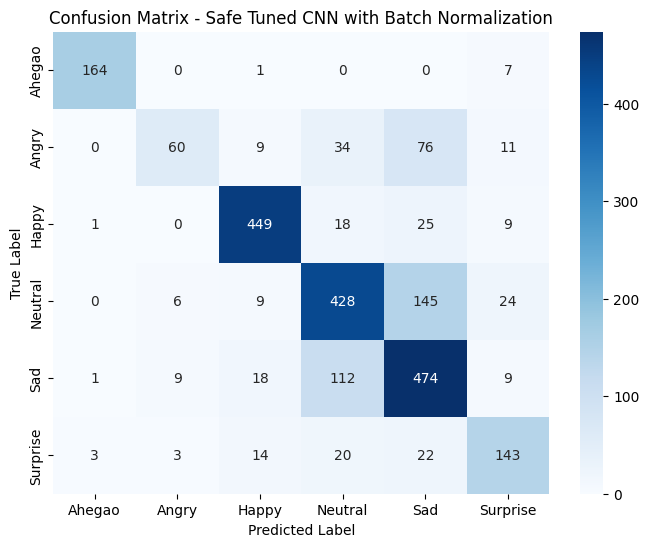

In [ ]:
cm_safe = confusion_matrix(y_true_safe, y_pred_safe)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_safe,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Safe Tuned CNN with Batch Normalization")
plt.show()

# Compare Simple CNN vs Tuned CNN

In [ ]:
print("Simple CNN Test Accuracy:", test_accuracy)
print("Safe Tuned CNN Test Accuracy:", test_accuracy_safe)

Simple CNN Test Accuracy: 0.5802951455116272
Safe Tuned CNN Test Accuracy: 0.7456597089767456


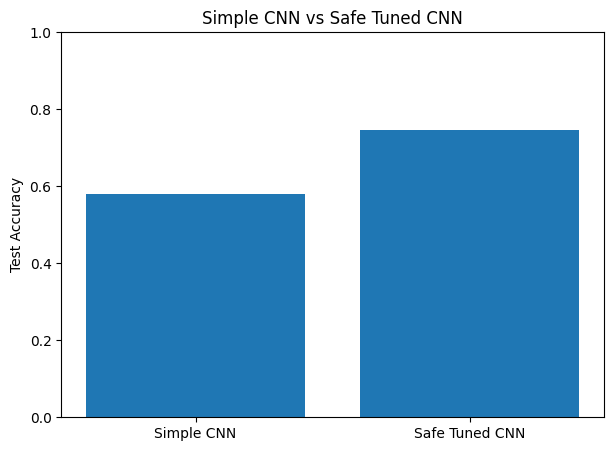

In [ ]:
model_names = ["Simple CNN", "Safe Tuned CNN"]
model_accuracies = [test_accuracy, test_accuracy_safe]

plt.figure(figsize=(7, 5))
plt.bar(model_names, model_accuracies)
plt.ylabel("Test Accuracy")
plt.title("Simple CNN vs Safe Tuned CNN")
plt.ylim(0, 1)
plt.show()

# Save the Tuned CNN Model

In [ ]:
best_safe_tuned_model.save("/content/drive/MyDrive/safe_tuned_cnn_bn_model.keras")

# 8. Appling Transfer Model

**Reloading the Dataset with 128x128 Image Size**

In [ ]:
dataset_path = "/content/drive/MyDrive/emotion-recognition-dataset/Dataset/dataset"

IMG_SIZE_tl = (128, 128)
BATCH_SIZE = 32
SEED = 42

In [ ]:
train_ds_tl = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE_tl,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

temp_ds_tl = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE_tl,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

Found 15454 files belonging to 6 classes.
Using 10818 files for training.
Found 15454 files belonging to 6 classes.
Using 4636 files for validation.


**Split the 30% validation portion into validation and test:**

In [ ]:
val_batches_tl = tf.data.experimental.cardinality(temp_ds_tl)

test_ds_tl = temp_ds_tl.take(val_batches_tl // 2)
val_ds_tl = temp_ds_tl.skip(val_batches_tl // 2)

class_names = train_ds_tl.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

Class names: ['Ahegao', 'Angry', 'Happy', 'Neutral', 'Sad', 'Surprise']
Number of classes: 6


# Recalculate Class Weights

Because we loaded a new dataset pipeline, recalculate class weights from the folder structure.

In [ ]:
import os

all_labels_tl = []

for class_index, class_name in enumerate(class_names):
    class_dir = os.path.join(dataset_path, class_name)

    image_files = [
        file for file in os.listdir(class_dir)
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ]

    all_labels_tl.extend([class_index] * len(image_files))

all_labels_tl = np.array(all_labels_tl)

class_weights_values_tl = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(all_labels_tl),
    y=all_labels_tl
)

class_weights_tl = {
    i: class_weights_values_tl[i]
    for i in range(len(class_weights_values_tl))
}

print("Class weights for VGG16:")
print(class_weights_tl)

Class weights for VGG16:
{0: np.float64(2.1357103372028745), 1: np.float64(1.9616653973089617), 2: np.float64(0.6886809269162211), 3: np.float64(0.6395993709130039), 4: np.float64(0.6547195390611761), 5: np.float64(2.0872501350621286)}


**Improve Dataset Loading Speed**

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds_tl = train_ds_tl.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds_tl = val_ds_tl.cache().prefetch(buffer_size=AUTOTUNE)
test_ds_tl = test_ds_tl.cache().prefetch(buffer_size=AUTOTUNE)

**Data Augmentation for VGG16**

In [ ]:
data_augmentation_tl= tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
], name="data_augmentation_vgg16")

# Appling DenseNet121 Model

In [ ]:

IMG_SHAPE_tl = (128, 128, 3)
base_model = DenseNet121(
    input_shape=IMG_SHAPE_tl,
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


**Now build the full model:**

In [ ]:
inputs = layers.Input(shape=IMG_SHAPE_tl )

x = data_augmentation_tl(inputs)


x = preprocess_input(x)

# Frozen feature extractor
x = base_model (x, training=False)

# Classification head
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

tl_model = models.Model(inputs, outputs)

# Model Summery

In [ ]:
tl_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation_vgg16         │ (None, 128, 128, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 4, 4, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,335,110 (27.98 MB)

 Trainable params: 296,838 (1.13 MB)

 Non-trainable params: 7,038,272 (26.85 MB)

**Compile the Model**

In [ ]:
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

**Train Only the New Classification Head**

In [ ]:
early_stopping_tl = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr_tl = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

**Training Transfer Learning Model**

In [ ]:
history = tl_model.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=25,
    callbacks=[early_stopping_tl, reduce_lr_tl]
)

Epoch 1/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 75s 57ms/step - accuracy: 0.4226 - loss: 1.6783 - val_accuracy: 0.5515 - val_loss: 1.1816 - learning_rate: 0.0010
Epoch 2/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.5178 - loss: 1.2508 - val_accuracy: 0.5648 - val_loss: 1.0760 - learning_rate: 0.0010
Epoch 3/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.5527 - loss: 1.1470 - val_accuracy: 0.5806 - val_loss: 1.0231 - learning_rate: 0.0010
Epoch 4/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.5710 - loss: 1.0847 - val_accuracy: 0.6016 - val_loss: 1.0027 - learning_rate: 0.0010
Epoch 5/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.5793 - loss: 1.0675 - val_accuracy: 0.6003 - val_loss: 1.0126 - learning_rate: 0.0010
Epoch 6/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.5840 - loss: 1.0360 - val_accuracy: 0.6055 - val_loss: 0.9920 - learning_rate: 0.0010
Epoch 7/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.5904 - loss: 1

**Plot Training Results**

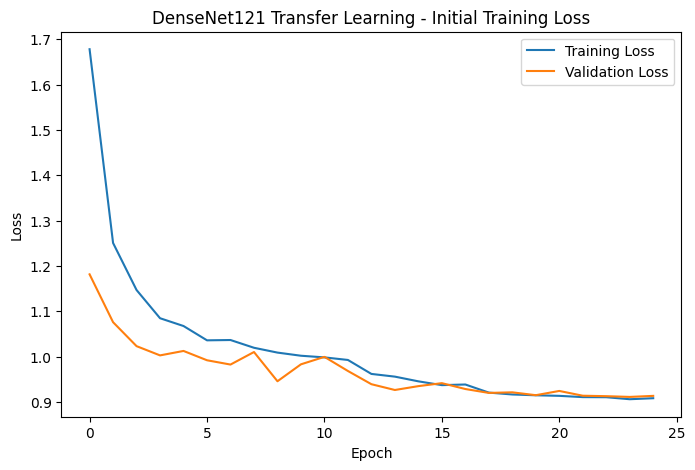

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DenseNet121 Transfer Learning - Initial Training Loss")
plt.legend()
plt.show()

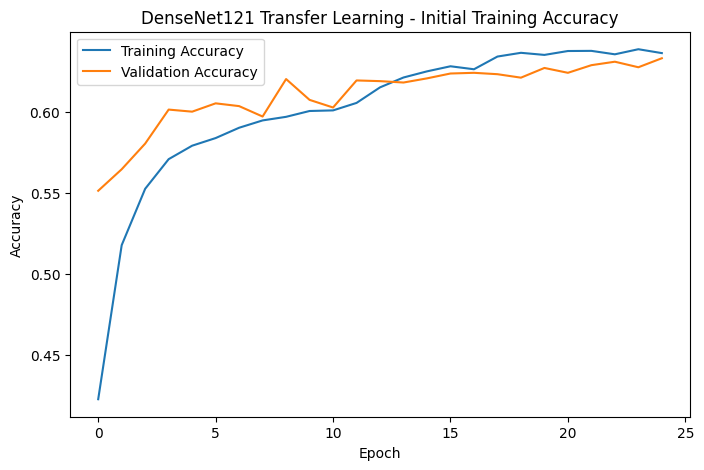

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DenseNet121 Transfer Learning - Initial Training Accuracy")
plt.legend()
plt.show()

# Result of Transfer Learning Model on Test Set

In [ ]:
test_loss_tl, test_accuracy_tl = tl_model.evaluate(test_ds_tl)

print(f"Initial Transfer Learning Test Loss: {test_loss_tl:.4f}")
print(f"Initial Transfer Learning Test Accuracy: {test_accuracy_tl:.4f}")

72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.6359 - loss: 0.9270
Initial Transfer Learning Test Loss: 0.9270
Initial Transfer Learning Test Accuracy: 0.6359


In [ ]:
y_true_tl = []
y_pred_tl = []

for images, labels in test_ds_tl:
    predictions = tl_model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    y_true_tl.extend(labels.numpy())
    y_pred_tl.extend(predicted_classes)

y_true_tl = np.array(y_true_tl)
y_pred_tl = np.array(y_pred_tl)

# Classification Report for CNN

In [ ]:
print(classification_report(
    y_true_tl,
    y_pred_tl,
    target_names=class_names
))

              precision    recall  f1-score   support

      Ahegao       0.79      0.95      0.86       172
       Angry       0.71      0.26      0.38       190
       Happy       0.71      0.77      0.74       502
     Neutral       0.56      0.66      0.61       612
         Sad       0.59      0.60      0.59       623
    Surprise       0.65      0.43      0.52       205

    accuracy                           0.64      2304
   macro avg       0.67      0.61      0.62      2304
weighted avg       0.64      0.64      0.63      2304



# Confusion Matrix for Transfer Learning Model

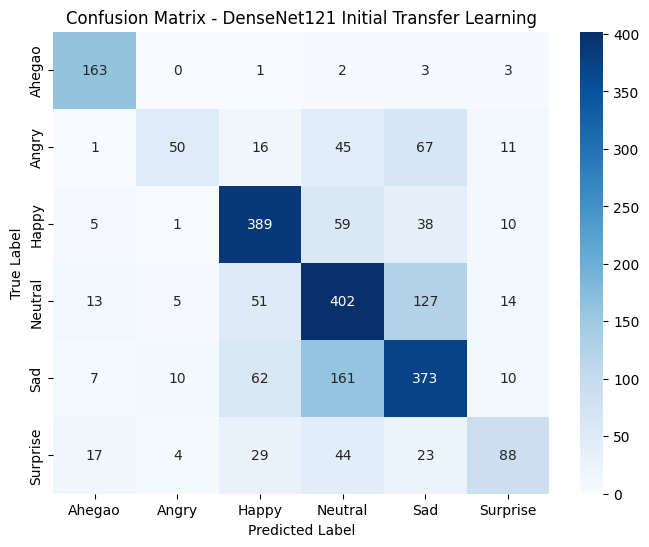

In [ ]:
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_tl,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - DenseNet121 Initial Transfer Learning")
plt.show()

# 9 Fine-Tune TL model

In [ ]:
base_model.trainable = True

**Freeze the first 70% of layers and train only the last 30%:**

In [ ]:
fine_tune_at = int(len(base_model.layers) * 0.7)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

**Keep Batch Normalization layers frozen. This usually makes fine-tuning more stable.**

In [ ]:
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

for i, layer in enumerate(base_model.layers):
    print(i, layer.name, layer.trainable)

0 input_layer_2 False
1 zero_padding2d False
2 conv1_conv False
3 conv1_bn False
4 conv1_relu False
5 zero_padding2d_1 False
6 pool1 False
7 conv2_block1_0_bn False
8 conv2_block1_0_relu False
9 conv2_block1_1_conv False
10 conv2_block1_1_bn False
11 conv2_block1_1_relu False
12 conv2_block1_2_conv False
13 conv2_block1_concat False
14 conv2_block2_0_bn False
15 conv2_block2_0_relu False
16 conv2_block2_1_conv False
17 conv2_block2_1_bn False
18 conv2_block2_1_relu False
19 conv2_block2_2_conv False
20 conv2_block2_concat False
21 conv2_block3_0_bn False
22 conv2_block3_0_relu False
23 conv2_block3_1_conv False
24 conv2_block3_1_bn False
25 conv2_block3_1_relu False
26 conv2_block3_2_conv False
27 conv2_block3_concat False
28 conv2_block4_0_bn False
29 conv2_block4_0_relu False
30 conv2_block4_1_conv False
31 conv2_block4_1_bn False
32 conv2_block4_1_relu False
33 conv2_block4_2_conv False
34 conv2_block4_concat False
35 conv2_block5_0_bn False
36 conv2_block5_0_relu False
37 conv2_blo

# Recompile with a Lower Learning Rate

In [ ]:
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Resetting the Call Backs

In [ ]:
early_stopping_tl_fine = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr_tl_fine = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# Traning the Fine Tunned Model

In [ ]:
history_fine = tl_model.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=25,
    callbacks=[early_stopping_tl_fine, reduce_lr_tl_fine]
)

Epoch 1/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 40s 56ms/step - accuracy: 0.6521 - loss: 0.8881 - val_accuracy: 0.6445 - val_loss: 0.8889 - learning_rate: 1.0000e-05
Epoch 2/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.6590 - loss: 0.8486 - val_accuracy: 0.6672 - val_loss: 0.8331 - learning_rate: 1.0000e-05
Epoch 3/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.6771 - loss: 0.8098 - val_accuracy: 0.6775 - val_loss: 0.8025 - learning_rate: 1.0000e-05
Epoch 4/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.6864 - loss: 0.7911 - val_accuracy: 0.6840 - val_loss: 0.7884 - learning_rate: 1.0000e-05
Epoch 5/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.7014 - loss: 0.7644 - val_accuracy: 0.6964 - val_loss: 0.7537 - learning_rate: 1.0000e-05
Epoch 6/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.7044 - loss: 0.7430 - val_accuracy: 0.6951 - val_loss: 0.7603 - learning_rate: 1.0000e-05
Epoch 7/25
339/339 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/ste

# Training Curves for Tunned TF model

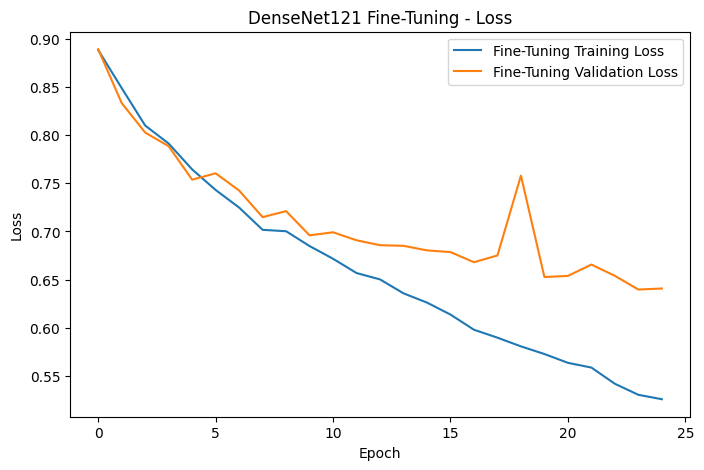

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_fine.history["loss"], label="Fine-Tuning Training Loss")
plt.plot(history_fine.history["val_loss"], label="Fine-Tuning Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DenseNet121 Fine-Tuning - Loss")
plt.legend()
plt.show()

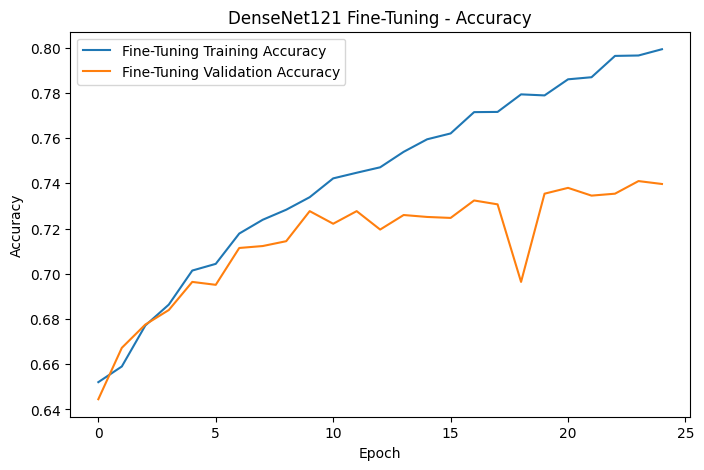

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_fine.history["accuracy"], label="Fine-Tuning Training Accuracy")
plt.plot(history_fine.history["val_accuracy"], label="Fine-Tuning Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DenseNet121 Fine-Tuning - Accuracy")
plt.legend()
plt.show()

# Evaluate Fine-Tuned Model

In [ ]:
test_loss_tl_fine, test_accuracy_tl_fine = tl_model.evaluate(test_ds_tl)

print(f"Fine-Tuned Transfer Learning Test Loss: {test_loss_tl_fine:.4f}")
print(f"Fine-Tuned Transfer Learning Test Accuracy: {test_accuracy_tl_fine:.4f}")

72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7383 - loss: 0.6530
Fine-Tuned Transfer Learning Test Loss: 0.6530
Fine-Tuned Transfer Learning Test Accuracy: 0.7383


# Classification Report After Fine-Tuning

In [ ]:
y_true_tl_fine = []
y_pred_tl_fine = []

for images, labels in test_ds_tl:
    predictions = tl_model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    y_true_tl_fine.extend(labels.numpy())
    y_pred_tl_fine.extend(predicted_classes)

y_true_tl_fine = np.array(y_true_tl_fine)
y_pred_tl_fine = np.array(y_pred_tl_fine)

In [ ]:
print(classification_report(
    y_true_tl_fine,
    y_pred_tl_fine,
    target_names=class_names
))

              precision    recall  f1-score   support

      Ahegao       0.92      0.98      0.95       172
       Angry       0.79      0.46      0.58       190
       Happy       0.85      0.90      0.87       502
     Neutral       0.64      0.73      0.68       612
         Sad       0.68      0.66      0.67       623
    Surprise       0.78      0.67      0.72       205

    accuracy                           0.74      2304
   macro avg       0.78      0.73      0.75      2304
weighted avg       0.74      0.74      0.74      2304



# Confusion Matrix After Fine-Tuning

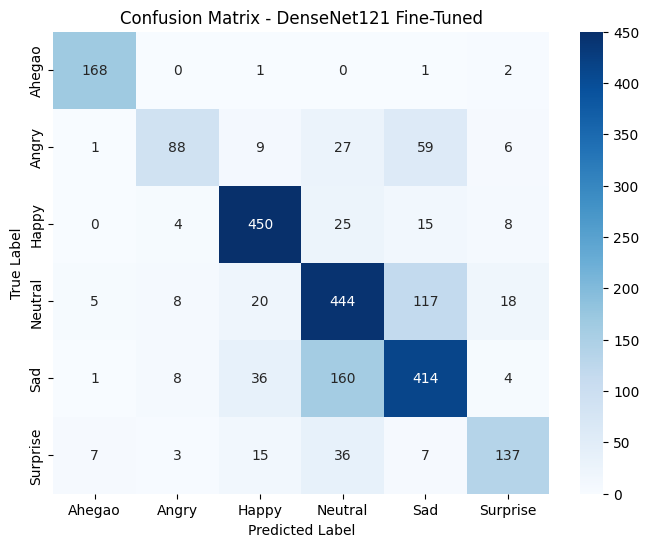

In [ ]:
cm_tl_fine = confusion_matrix(y_true_tl_fine, y_pred_tl_fine)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_tl_fine,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - DenseNet121 Fine-Tuned")
plt.show()

# Compare Before and After Fine-Tuning

In [ ]:
print("Initial Transfer Learning Accuracy:", test_accuracy_tl)
print("Fine-Tuned Transfer Learning Accuracy:", test_accuracy_tl_fine)

Initial Transfer Learning Accuracy: 0.6358506679534912
Fine-Tuned Transfer Learning Accuracy: 0.73828125


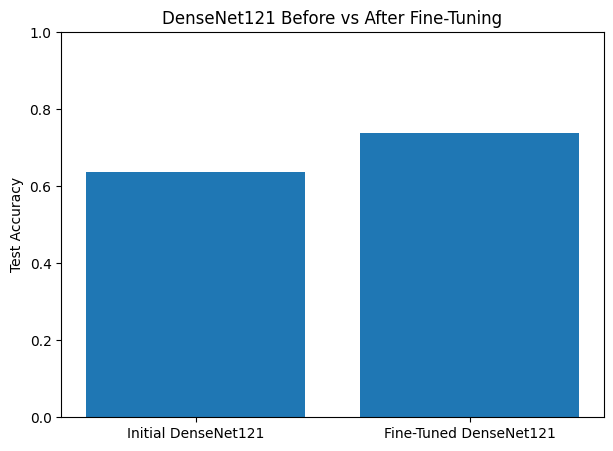

In [ ]:
model_names = ["Initial DenseNet121", "Fine-Tuned DenseNet121"]
model_accuracies = [test_accuracy_tl, test_accuracy_tl_fine]

plt.figure(figsize=(7, 5))
plt.bar(model_names, model_accuracies)
plt.ylabel("Test Accuracy")
plt.title("DenseNet121 Before vs After Fine-Tuning")
plt.ylim(0, 1)
plt.show()

# Compare with Previous CNN Models

In [ ]:
test_accuracy          # Simple CNN
test_accuracy_safe     # Tuned CNN
test_accuracy_tl_fine  # DenseNet121 fine-tuned model

0.73828125

In [ ]:
print("Simple CNN Test Accuracy:", test_accuracy)
print("Tuned CNN Test Accuracy:", test_accuracy_safe)
print("DenseNet121 Fine-Tuned Test Accuracy:", test_accuracy_tl_fine)

Simple CNN Test Accuracy: 0.5802951455116272
Tuned CNN Test Accuracy: 0.7456597089767456
DenseNet121 Fine-Tuned Test Accuracy: 0.73828125


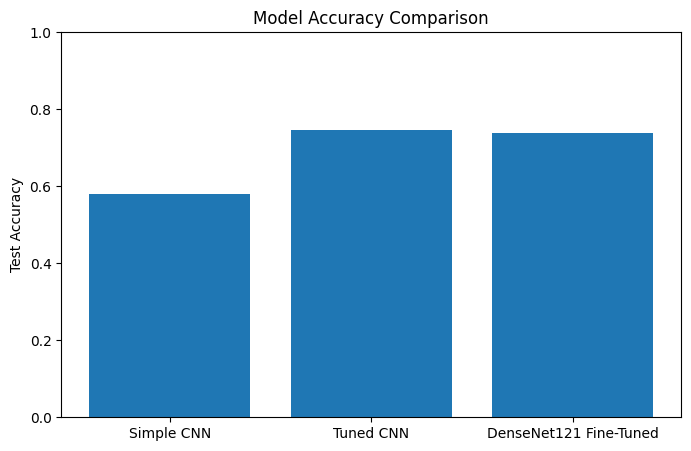

In [ ]:
model_names = [
    "Simple CNN",
    "Tuned CNN",
    "DenseNet121 Fine-Tuned"
]

model_accuracies = [
    test_accuracy,
    test_accuracy_safe,
    test_accuracy_tl_fine
]

plt.figure(figsize=(8, 5))
plt.bar(model_names, model_accuracies)
plt.ylabel("Test Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.show()

In [ ]:
tl_model.save("/content/drive/MyDrive/densenet121_transfer_model.keras")

# 10. VIT

**ViT is implemented using PyTorch because the TensorFlow/Hugging Face ViT caused package conflicts in Colab.**

In [ ]:
!pip install -q transformers datasets accelerate

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler

from torchvision import datasets, transforms
from transformers import ViTForImageClassification

from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

Using device: cuda


**Dataset path**

In [ ]:
dataset_path = "/content/drive/MyDrive/emotion-recognition-dataset/Dataset/dataset"

# ViT transforms

In [ ]:
vit_train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

vit_test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

# Load dataset

In [ ]:
full_dataset_vit = datasets.ImageFolder(
    root=dataset_path,
    transform=vit_train_transform
)

class_names_vit = full_dataset_vit.classes
num_classes_vit = len(class_names_vit)

print("Classes:", class_names_vit)
print("Number of classes:", num_classes_vit)
print("Total images:", len(full_dataset_vit))

Classes: ['Ahegao', 'Angry', 'Happy', 'Neutral', 'Sad', 'Surprise']
Number of classes: 6
Total images: 15454


# Train/validation/test split

In [ ]:
total_size = len(full_dataset_vit)

train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_dataset_vit, val_dataset_vit, test_dataset_vit = random_split(
    full_dataset_vit,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

print("Train size:", len(train_dataset_vit))
print("Validation size:", len(val_dataset_vit))
print("Test size:", len(test_dataset_vit))

Train size: 10817
Validation size: 2318
Test size: 2319


# Apply test transform to validation/test sets

In [ ]:
from PIL import Image

class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
        self.dataset = subset.dataset

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        original_idx = self.subset.indices[idx]
        image_path, label = self.dataset.samples[original_idx]

        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)

        return image, label

In [ ]:
train_data_vit = TransformSubset(train_dataset_vit, vit_train_transform)
val_data_vit = TransformSubset(val_dataset_vit, vit_test_transform)
test_data_vit = TransformSubset(test_dataset_vit, vit_test_transform)

# Handle class imbalance with sampler

In [ ]:
from collections import Counter
from torch.utils.data import WeightedRandomSampler

train_labels_vit = [
    full_dataset_vit.samples[idx][1]
    for idx in train_dataset_vit.indices
]

class_counts_vit = Counter(train_labels_vit)
print("Training class counts:", class_counts_vit)

class_weights_vit = {
    class_idx: 1.0 / count
    for class_idx, count in class_counts_vit.items()
}

sample_weights_vit = [
    class_weights_vit[label]
    for label in train_labels_vit
]

sampler_vit = WeightedRandomSampler(
    weights=sample_weights_vit,
    num_samples=len(sample_weights_vit),
    replacement=True
)

Training class counts: Counter({3: 2858, 4: 2693, 2: 2633, 1: 912, 5: 866, 0: 855})


# DataLoaders

In [ ]:
BATCH_SIZE_VIT = 16

train_loader_vit = DataLoader(
    train_data_vit,
    batch_size=BATCH_SIZE_VIT,
    sampler=sampler_vit,
    num_workers=2
)

val_loader_vit = DataLoader(
    val_data_vit,
    batch_size=BATCH_SIZE_VIT,
    shuffle=False,
    num_workers=2
)

test_loader_vit = DataLoader(
    test_data_vit,
    batch_size=BATCH_SIZE_VIT,
    shuffle=False,
    num_workers=2
)

images, labels = next(iter(train_loader_vit))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([16, 3, 128, 128])
Label batch shape: torch.Size([16])


Load pretrained ViT model

In [ ]:
vit_model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224-in21k",
    num_labels=num_classes_vit,
    id2label={i: label for i, label in enumerate(class_names_vit)},
    label2id={label: i for i, label in enumerate(class_names_vit)},
    ignore_mismatched_sizes=True
)

vit_model = vit_model.to(device)

print("ViT model loaded successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/6 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
encoder.layer.{0...11}.attention.attention.query.bias   | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.value.bias   | UNEXPECTED | 
encoder.layer.{0...11}.attention.output.dense.bias      | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.value.weight | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.key.bias     | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.key.weight   | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.bias             | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.query.weight | UNEXPECTED | 
encoder.layer.{0...11}.output.dense.weight              | UNEXPECTED | 
encoder.layer.{0...11}.intermediate.dense.bias          | UNEXPECTED | 
pooler.dense.weight                        

ViT model loaded successfully


Freez Most of Model L;ayers

In [ ]:
for param in vit_model.vit.parameters():
    param.requires_grad = False

# Train classifier head only first
for param in vit_model.classifier.parameters():
    param.requires_grad = True

print("ViT backbone frozen. Classifier head is trainable.")

ViT backbone frozen. Classifier head is trainable.


# Loss and optimizer

In [ ]:
criterion_vit = nn.CrossEntropyLoss()

optimizer_vit = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, vit_model.parameters()),
    lr=2e-4,
    weight_decay=0.01
)

print("Loss function and optimizer are ready.")

Loss function and optimizer are ready.


# Training and validation functions

In [ ]:
def train_one_epoch_vit(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(
            pixel_values=images,
            interpolate_pos_encoding=True
        )

        logits = outputs.logits
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(logits, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

In [ ]:
def evaluate_vit(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(
                pixel_values=images,
                interpolate_pos_encoding=True
            )

            logits = outputs.logits
            loss = criterion(logits, labels)

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(logits, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

# Train ViT classifier head

In [ ]:
EPOCHS_VIT = 25

vit_train_losses = []
vit_val_losses = []
vit_train_accs = []
vit_val_accs = []

best_val_acc_vit = 0.0
best_vit_path = "/content/best_vit_emotion_model.pth"

patience = 5
patience_counter = 0

for epoch in range(EPOCHS_VIT):
    train_loss, train_acc = train_one_epoch_vit(
        vit_model,
        train_loader_vit,
        criterion_vit,
        optimizer_vit,
        device
    )

    val_loss, val_acc = evaluate_vit(
        vit_model,
        val_loader_vit,
        criterion_vit,
        device
    )

    vit_train_losses.append(train_loss)
    vit_val_losses.append(val_loss)
    vit_train_accs.append(train_acc)
    vit_val_accs.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS_VIT}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_val_acc_vit:
        best_val_acc_vit = val_acc
        patience_counter = 0
        torch.save(vit_model.state_dict(), best_vit_path)
        print("Best ViT model saved.")
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping triggered.")
        break

print(f"Best Validation Accuracy: {best_val_acc_vit:.4f}")

Epoch [1/25] Train Loss: 1.7241 | Train Acc: 0.2610 | Val Loss: 1.7135 | Val Acc: 0.2714
Best ViT model saved.
Epoch [2/25] Train Loss: 1.6839 | Train Acc: 0.2980 | Val Loss: 1.7215 | Val Acc: 0.2442
Epoch [3/25] Train Loss: 1.6663 | Train Acc: 0.2980 | Val Loss: 1.7084 | Val Acc: 0.2653
Epoch [4/25] Train Loss: 1.6572 | Train Acc: 0.3016 | Val Loss: 1.6843 | Val Acc: 0.2567
Epoch [5/25] Train Loss: 1.6428 | Train Acc: 0.3116 | Val Loss: 1.6836 | Val Acc: 0.2959
Best ViT model saved.
Epoch [6/25] Train Loss: 1.6386 | Train Acc: 0.3144 | Val Loss: 1.6541 | Val Acc: 0.3184
Best ViT model saved.
Epoch [7/25] Train Loss: 1.6260 | Train Acc: 0.3212 | Val Loss: 1.6563 | Val Acc: 0.2964
Epoch [8/25] Train Loss: 1.6283 | Train Acc: 0.3278 | Val Loss: 1.6592 | Val Acc: 0.2951
Epoch [9/25] Train Loss: 1.6315 | Train Acc: 0.3225 | Val Loss: 1.6600 | Val Acc: 0.3041
Epoch [10/25] Train Loss: 1.6178 | Train Acc: 0.3342 | Val Loss: 1.6266 | Val Acc: 0.3318
Best ViT model saved.
Epoch [11/25] Train L

# 11 Fine-tune last ViT blocks

In [ ]:
# Load the best classifier-head model before fine-tuning
vit_model.load_state_dict(torch.load(best_vit_path, map_location=device))
vit_model = vit_model.to(device)

# Freeze all parameters first
for param in vit_model.parameters():
    param.requires_grad = False

# Print model structure to check names
print("ViT backbone children:")
for name, module in vit_model.vit.named_children():
    print(name)

ViT backbone children:
embeddings
layers
layernorm


In [ ]:
# Unfreeze classifier head
for param in vit_model.classifier.parameters():
    param.requires_grad = True

# Try to find transformer blocks automatically
transformer_blocks = None

if hasattr(vit_model.vit, "encoder"):
    if hasattr(vit_model.vit.encoder, "layer"):
        transformer_blocks = vit_model.vit.encoder.layer
    elif hasattr(vit_model.vit.encoder, "layers"):
        transformer_blocks = vit_model.vit.encoder.layers

elif hasattr(vit_model.vit, "layers"):
    transformer_blocks = vit_model.vit.layers

elif hasattr(vit_model.vit, "layer"):
    transformer_blocks = vit_model.vit.layer

# Unfreeze last 2 blocks if found
if transformer_blocks is not None:
    for block in transformer_blocks[-2:]:
        for param in block.parameters():
            param.requires_grad = True

    print("Last 2 ViT transformer blocks are unfrozen.")
else:
    print("Transformer blocks not found. Only classifier head will be fine-tuned.")

optimizer_vit_fine = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, vit_model.parameters()),
    lr=1e-5,
    weight_decay=0.01
)

print("Fine-tuning optimizer is ready.")

Last 2 ViT transformer blocks are unfrozen.
Fine-tuning optimizer is ready.


In [ ]:
trainable_params = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in vit_model.parameters())

print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters: {total_params:,}")

Trainable parameters: 14,180,358
Total parameters: 85,803,270


In [ ]:
EPOCHS_VIT_FINE = 25

vit_fine_train_losses = []
vit_fine_val_losses = []
vit_fine_train_accs = []
vit_fine_val_accs = []

patience_fine = 3
patience_counter_fine = 0

for epoch in range(EPOCHS_VIT_FINE):
    train_loss, train_acc = train_one_epoch_vit(
        vit_model,
        train_loader_vit,
        criterion_vit,
        optimizer_vit_fine,
        device
    )

    val_loss, val_acc = evaluate_vit(
        vit_model,
        val_loader_vit,
        criterion_vit,
        device
    )

    vit_fine_train_losses.append(train_loss)
    vit_fine_val_losses.append(val_loss)
    vit_fine_train_accs.append(train_acc)
    vit_fine_val_accs.append(val_acc)

    print(
        f"Fine-Tune Epoch [{epoch+1}/{EPOCHS_VIT_FINE}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_val_acc_vit:
        best_val_acc_vit = val_acc
        patience_counter_fine = 0
        torch.save(vit_model.state_dict(), best_vit_path)
        print("Best fine-tuned ViT model saved.")
    else:
        patience_counter_fine += 1

    if patience_counter_fine >= patience_fine:
        print("Fine-tuning early stopping triggered.")
        break

print(f"Best ViT Validation Accuracy After Fine-Tuning: {best_val_acc_vit:.4f}")

Fine-Tune Epoch [1/25] Train Loss: 1.5509 | Train Acc: 0.3664 | Val Loss: 1.4924 | Val Acc: 0.3624
Best fine-tuned ViT model saved.
Fine-Tune Epoch [2/25] Train Loss: 1.4214 | Train Acc: 0.4179 | Val Loss: 1.4488 | Val Acc: 0.3840
Best fine-tuned ViT model saved.
Fine-Tune Epoch [3/25] Train Loss: 1.3212 | Train Acc: 0.4718 | Val Loss: 1.3928 | Val Acc: 0.4193
Best fine-tuned ViT model saved.
Fine-Tune Epoch [4/25] Train Loss: 1.2357 | Train Acc: 0.5068 | Val Loss: 1.3725 | Val Acc: 0.4353
Best fine-tuned ViT model saved.
Fine-Tune Epoch [5/25] Train Loss: 1.1730 | Train Acc: 0.5367 | Val Loss: 1.2023 | Val Acc: 0.5104
Best fine-tuned ViT model saved.
Fine-Tune Epoch [6/25] Train Loss: 1.1050 | Train Acc: 0.5691 | Val Loss: 1.1868 | Val Acc: 0.5259
Best fine-tuned ViT model saved.
Fine-Tune Epoch [7/25] Train Loss: 1.0763 | Train Acc: 0.5731 | Val Loss: 1.1624 | Val Acc: 0.5237
Fine-Tune Epoch [8/25] Train Loss: 1.0326 | Train Acc: 0.5935 | Val Loss: 1.1268 | Val Acc: 0.5509
Best fine-

# Plot ViT results

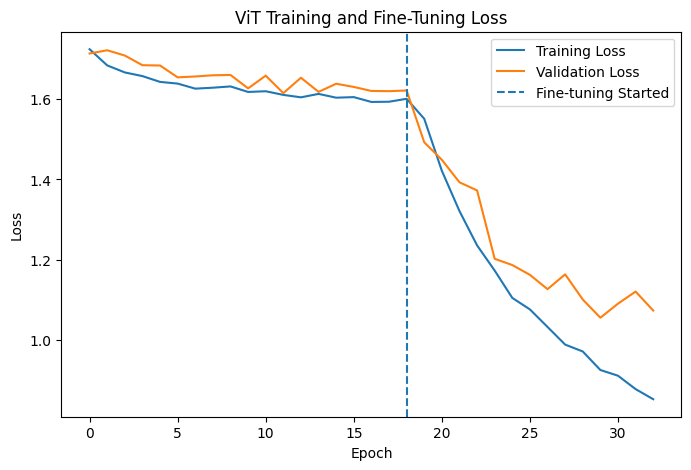

In [ ]:
# Combine classifier-head training history + fine-tuning history
vit_total_train_losses = vit_train_losses + vit_fine_train_losses
vit_total_val_losses = vit_val_losses + vit_fine_val_losses

plt.figure(figsize=(8, 5))
plt.plot(vit_total_train_losses, label="Training Loss")
plt.plot(vit_total_val_losses, label="Validation Loss")

# Mark where fine-tuning started
plt.axvline(
    x=len(vit_train_losses) - 1,
    linestyle="--",
    label="Fine-tuning Started"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ViT Training and Fine-Tuning Loss")
plt.legend()
plt.show()

# Evaluate ViT on Test Set

In [ ]:
vit_model.load_state_dict(torch.load(best_vit_path, map_location=device))
vit_model = vit_model.to(device)

test_loss_vit, test_accuracy_vit = evaluate_vit(
    vit_model,
    test_loader_vit,
    criterion_vit,
    device
)

print(f"ViT Test Loss: {test_loss_vit:.4f}")
print(f"ViT Test Accuracy: {test_accuracy_vit:.4f}")

ViT Test Loss: 1.0876
ViT Test Accuracy: 0.5563


# Classification Report

In [ ]:
y_true_vit = []
y_pred_vit = []

vit_model.eval()

with torch.no_grad():
    for images, labels in test_loader_vit:
        images = images.to(device)
        labels = labels.to(device)

        outputs = vit_model(
            pixel_values=images,
            interpolate_pos_encoding=True
        )

        logits = outputs.logits
        _, preds = torch.max(logits, 1)

        y_true_vit.extend(labels.cpu().numpy())
        y_pred_vit.extend(preds.cpu().numpy())

In [ ]:
print(classification_report(
    y_true_vit,
    y_pred_vit,
    target_names=class_names_vit,
    digits=4
))

              precision    recall  f1-score   support

      Ahegao     0.7135    0.8562    0.7784       160
       Angry     0.3656    0.3366    0.3505       202
       Happy     0.6835    0.7049    0.6940       576
     Neutral     0.5344    0.4714    0.5009       577
         Sad     0.5109    0.4976    0.5041       615
    Surprise     0.4226    0.5344    0.4720       189

    accuracy                         0.5563      2319
   macro avg     0.5384    0.5669    0.5500      2319
weighted avg     0.5537    0.5563    0.5534      2319



# Confusion Matrix

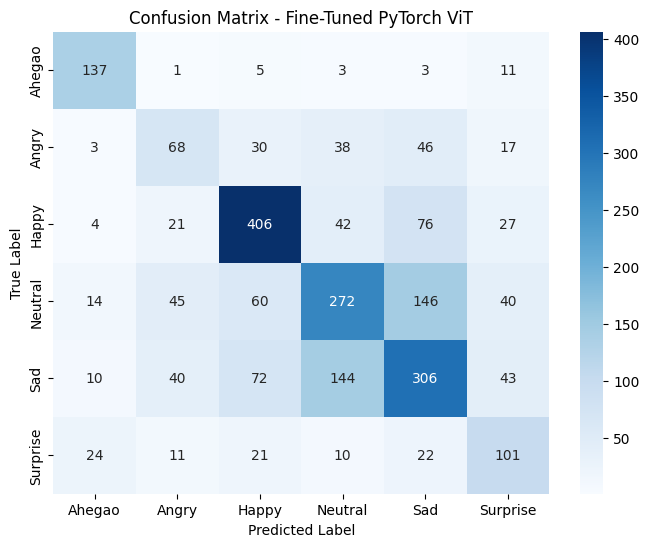

In [ ]:
cm_vit = confusion_matrix(y_true_vit, y_pred_vit)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_vit,
    annot=True,
    fmt="d",
    xticklabels=class_names_vit,
    yticklabels=class_names_vit,
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Fine-Tuned PyTorch ViT")
plt.show()

# Compare All Models

In [ ]:
print("Simple CNN Test Accuracy:", test_accuracy)
print("Tuned CNN Test Accuracy:", test_accuracy_safe)
print("DenseNet121 Test Accuracy:", test_accuracy_tl_fine)
print("PyTorch ViT Test Accuracy:", test_accuracy_vit)

Simple CNN Test Accuracy: 0.5802951455116272
Tuned CNN Test Accuracy: 0.7456597089767456
DenseNet121 Test Accuracy: 0.73828125
PyTorch ViT Test Accuracy: 0.55627425614489


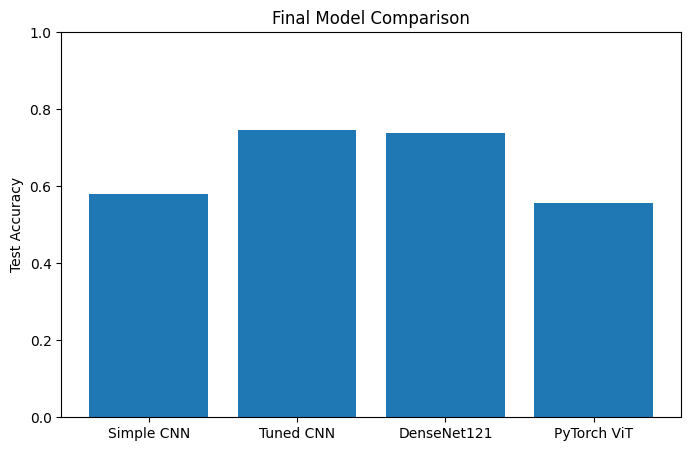

In [ ]:
model_names = [
    "Simple CNN",
    "Tuned CNN",
    "DenseNet121",
    "PyTorch ViT"
]

model_accuracies = [
    test_accuracy,
    test_accuracy_safe,
    test_accuracy_tl_fine,
    test_accuracy_vit
]

plt.figure(figsize=(8, 5))
plt.bar(model_names, model_accuracies)
plt.ylabel("Test Accuracy")
plt.title("Final Model Comparison")
plt.ylim(0, 1)
plt.show()